# Tweets - NLP & Sentiment Analysis


In [153]:
## IMPORTS ## 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.svm import LinearSVC
from scipy.special import softmax

from sklearn.naive_bayes import MultinomialNB
from gensim.models import Word2Vec

In [132]:
## CHARGEMENT + PREPROCESSING 18 DIFFERENT WAYS

def load_tweets(file_path, sentiment):
    with open(file_path, "r", encoding="utf-8") as file:
        content = file.read()

    tweets = [tweet.strip() for tweet in content.split(",") if tweet.strip()]

    df = pd.DataFrame({
        "tweet": tweets,
        "sentiment": sentiment
    })

    return df
negative = load_tweets("../Data/processedNegative.csv", "negative")
positive = load_tweets("../Data/processedPositive.csv", "positive")
neutral = load_tweets("../Data/processedNeutral.csv", "neutral")

# Shuffle the complete dataset
df = pd.concat([negative, positive, neutral], ignore_index=True)
# Mélanger les tweets
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.to_csv(
    "../Data/preprocessed_data/D1_Original.csv",
    index=False
)


## TEXT TO LOWER CASE ##
df_lowercase = df.copy()

df_lowercase["tweet"] = df_lowercase["tweet"].str.lower()
df_lowercase.to_csv(
    "../Data/preprocessed_data/D2_Lowercase.csv",
    index=False
)

## TEXT WITHOUT PONCTUATION ##
df_punctuation = df_lowercase.copy()

df_punctuation["tweet"] = df_punctuation["tweet"].apply(
    lambda text: text.translate(str.maketrans("", "", string.punctuation))
)
df_punctuation.to_csv(
    "../Data/preprocessed_data/D3_Lowercase_Punctuation.csv",
    index=False
)

## TEXT AVEC STOPWORD ( the , he , i , you , she)
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
df_stopwords = df_lowercase.copy()
df_stopwords["tweet"] = df_stopwords["tweet"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)
df_stopwords.to_csv(
    "../Data/preprocessed_data/D4_Lowercase_Stopwords.csv",
    index=False
)

## TEXT STEMMING ( played ,  playing , is playing == play)
stemmer = PorterStemmer()
df_stemming = df_lowercase.copy()
df_stemming["tweet"] = df_stemming["tweet"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.split()
    )
)
df_stemming.to_csv(
    "../Data/preprocessed_data/D5_Lowercase_Stemming.csv",
    index=False
)

## TEXT COMBINAISON ENTRE LES 3
df_stem_stopwords = df_lowercase.copy()

df_stem_stopwords["tweet"] = df_stem_stopwords["tweet"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.split()
        if word not in stop_words
    )
)
df_stem_stopwords.to_csv(
    "../Data/preprocessed_data/D6_Lowercase_Stopwords_Stemming.csv",
    index=False
)

## TEXT COMBINAISON D3/D5
df_stem_punctuation = df_lowercase.copy()

df_stem_punctuation["tweet"] = df_stem_punctuation["tweet"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
    )
)
df_stem_punctuation.to_csv(
    "../Data/preprocessed_data/D7_Lowercase_Punctuation_Stemming.csv",
    index=False
)

## D8 — Lowercase + Punctuation + Stopwords
df_punct_stopwords = df_lowercase.copy()

df_punct_stopwords["tweet"] = df_punct_stopwords["tweet"].apply(
    lambda text: " ".join(
        word for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
        if word not in stop_words
    )
)

df_punct_stopwords.to_csv(
    "../Data/preprocessed_data/D8_Lowercase_Punctuation_Stopwords.csv",
    index=False
)

## D9 — Lowercase + Punctuation + Stopwords + Stemming
df_all_stemming = df_lowercase.copy()

df_all_stemming["tweet"] = df_all_stemming["tweet"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
        if word not in stop_words
    )
)

df_all_stemming.to_csv(
    "../Data/preprocessed_data/D9_Lowercase_Punctuation_Stopwords_Stemming.csv",
    index=False
)

## D10 — Lowercase + Lemmatization
nltk.download("wordnet")
nltk.download("omw-1.4")
df_lemma = df_lowercase.copy()
lemmatizer = WordNetLemmatizer()

df_lemma["tweet"] = df_lemma["tweet"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.split()
    )
)

df_lemma.to_csv(
    "../Data/preprocessed_data/D10_Lowercase_Lemmatization.csv",
    index=False
)

## D11 — Lowercase + Stopwords + Lemmatization

df_lemma_stopwords = df_lowercase.copy()

df_lemma_stopwords["tweet"] = df_lemma_stopwords["tweet"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    )
)

df_lemma_stopwords.to_csv(
    "../Data/preprocessed_data/D11_Lowercase_Stopwords_Lemmatization.csv",
    index=False
)

## D12 — Lowercase + Punctuation + Lemmatization
df_lemma_punctuation = df_lowercase.copy()

df_lemma_punctuation["tweet"] = df_lemma_punctuation["tweet"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
    )
)

df_lemma_punctuation.to_csv(
    "../Data/preprocessed_data/D12_Lowercase_Punctuation_Lemmatization.csv",
    index=False
)

## D13 — Lowercase + Punctuation + Stopwords + Lemmatization
df_all_lemma = df_lowercase.copy()

df_all_lemma["tweet"] = df_all_lemma["tweet"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
        if word not in stop_words
    )
)

df_all_lemma.to_csv(
    "../Data/preprocessed_data/D13_Lowercase_Punctuation_Stopwords_Lemmatization.csv",
    index=False
)

## D14 — Lowercase + Bigram
df_bigram = df_lowercase.copy()

df_bigram["tweet"] = df_bigram["tweet"].apply(
    lambda text: " ".join(
        " ".join(pair)
        for pair in ngrams(text.split(), 2)
    )
)

df_bigram.to_csv(
    "../Data/preprocessed_data/D14_Lowercase_Bigram.csv",
    index=False
)

## D15 — Lowercase + Trigram
df_trigram = df_lowercase.copy()

df_trigram["tweet"] = df_trigram["tweet"].apply(
    lambda text: " ".join(
        " ".join(trigram)
        for trigram in ngrams(text.split(), 3)
    )
)

df_trigram.to_csv(
    "../Data/preprocessed_data/D15_Lowercase_Trigram.csv",
    index=False
)

## D16 — Lowercase + Stopwords + Bigram
df_stopwords_bigram = df_lowercase.copy()

df_stopwords_bigram["tweet"] = df_stopwords_bigram["tweet"].apply(
    lambda text: " ".join(
        " ".join(pair)
        for pair in ngrams(
            [word for word in text.split() if word not in stop_words],
            2
        )
    )
)

df_stopwords_bigram.to_csv(
    "../Data/preprocessed_data/D16_Lowercase_Stopwords_Bigram.csv",
    index=False
)

## D17 — Lowercase + Lemmatization + Bigram
df_lemma_bigram = df_lowercase.copy()

df_lemma_bigram["tweet"] = df_lemma_bigram["tweet"].apply(
    lambda text: " ".join(
        " ".join(pair)
        for pair in ngrams(
            [lemmatizer.lemmatize(word) for word in text.split()],
            2
        )
    )
)

df_lemma_bigram.to_csv(
    "../Data/preprocessed_data/D17_Lowercase_Lemmatization_Bigram.csv",
    index=False
)

## D18 — Lowercase + Stopwords + Lemmatization + Bigram
df_final_preprocess = df_lowercase.copy()

df_final_preprocess["tweet"] = df_final_preprocess["tweet"].apply(
    lambda text: " ".join(
        " ".join(pair)
        for pair in ngrams(
            [
                lemmatizer.lemmatize(word)
                for word in text.split()
                if word not in stop_words
            ],
            2
        )
    )
)

df_final_preprocess.to_csv(
    "../Data/preprocessed_data/D18_Lowercase_Stopwords_Lemmatization_Bigram.csv",
    index=False
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lyamanichaimaa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/lyamanichaimaa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/lyamanichaimaa/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [133]:
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df["sentiment"].value_counts()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3865 entries, 0 to 3864
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet      3865 non-null   str  
 1   sentiment  3865 non-null   str  
dtypes: str(2)
memory usage: 60.5 KB


np.int64(413)

In [134]:
## COUNT BOW
def vectorize_bow(file_path):
    data = pd.read_csv(file_path)

    X = data["tweet"].fillna("")
    y = data["sentiment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    vectorizer = CountVectorizer()

    X_train_bow = vectorizer.fit_transform(X_train)
    X_test_bow = vectorizer.transform(X_test)

    return X_train_bow, X_test_bow, y_train, y_test, vectorizer
X_train_d1_bow, X_test_d1_bow, y_train_d1, y_test_d1, vectorizer_d1 = vectorize_bow(
    "../Data/preprocessed_data/D1_Original.csv"
)

bow_results = {}

for i in range(1, 19):
    pattern = f"../Data/preprocessed_data/D{i}_*.csv"
    file_path = glob.glob(pattern)[0]

    bow_results[f"D{i}"] = vectorize_bow(file_path)
# print("len of matrice is :", len(bow_results))
# print("Bow results0 ", bow_results["D1"][0].shape)
# print("Bow resultat1 : ",bow_results["D1"][1].shape)
# print(X_train_d1_bow[:3].toarray())

In [135]:
## BINARY BOW
def vectorize_binary(file_path):
    data = pd.read_csv(file_path)

    X = data["tweet"].fillna("")
    y = data["sentiment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    vectorizer = CountVectorizer(binary=True)

    X_train_binary = vectorizer.fit_transform(X_train)
    X_test_binary = vectorizer.transform(X_test)

    return X_train_binary, X_test_binary, y_train, y_test, vectorizer
X_train_d1_binary, X_test_d1_binary, y_train_d1_binary, y_test_d1_binary, vectorizer_d1_binary = vectorize_binary(
    "../Data/preprocessed_data/D1_Original.csv"
)

binary_results = {}

for i in range(1, 19):
    pattern = f"../Data/preprocessed_data/D{i}_*.csv"
    file_path = glob.glob(pattern)[0]

    binary_results[f"D{i}"] = vectorize_binary(file_path)
print("Number of datasets:", len(binary_results))
print("D1 train:", binary_results["D1"][0].shape)
print("D1 test:", binary_results["D1"][1].shape)
# print(X_train_d1_binary.shape)
# print(X_test_d1_binary.shape)
# print(X_train_d1_binary[:3].toarray())

Number of datasets: 18
D1 train: (3092, 5604)
D1 test: (773, 5604)


In [136]:
## TF-IDF Term Frequency – Inverse Document Frequency. (importance du mot)

def vectorize_tfidf(file_path):
    data = pd.read_csv(file_path)

    X = data["tweet"].fillna("")
    y = data["sentiment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    vectorizer = TfidfVectorizer()

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    return X_train_tfidf, X_test_tfidf, y_train, y_test, vectorizer
X_train_d1_tfidf, X_test_d1_tfidf, y_train_d1_tfidf, y_test_d1_tfidf, vectorizer_d1_tfidf = vectorize_tfidf(
    "../Data/preprocessed_data/D1_Original.csv"
)
print(X_train_d1_tfidf.shape)
print(X_test_d1_tfidf.shape)


tfidf_results = {}

for i in range(1, 19):
    pattern = f"../Data/preprocessed_data/D{i}_*.csv"
    file_path = glob.glob(pattern)[0]

    tfidf_results[f"D{i}"] = vectorize_tfidf(file_path)
print("Number of datasets:", len(tfidf_results))
print("D1 train:", tfidf_results["D1"][0].shape)
print("D1 test:", tfidf_results["D1"][1].shape)

(3092, 5604)
(773, 5604)
Number of datasets: 18
D1 train: (3092, 5604)
D1 test: (773, 5604)


In [137]:
## COSINE SIMILARITY

test_texts = {}

for i in range(1, 19):
    pattern = f"../Data/preprocessed_data/D{i}_*.csv"
    file_path = glob.glob(pattern)[0]

    data = pd.read_csv(file_path)

    X = data["tweet"].fillna("")
    y = data["sentiment"]

    _, X_test, _, _ = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    test_texts[f"D{i}"] = X_test

print(len(test_texts))
print(test_texts["D1"].shape)
print(test_texts["D18"].shape)

def get_top_similar_pairs(similarity_matrix, tweets, vector_matrix, n=10):
    tweets = tweets.reset_index(drop=True)

    # Indices du triangle supérieur uniquement
    rows, cols = np.triu_indices(
        similarity_matrix.shape[0],
        k=1
    )

    scores = similarity_matrix[rows, cols]

    # Créer une signature pour chaque vecteur
    vector_signatures = []

    for i in range(vector_matrix.shape[0]):
        row = vector_matrix.getrow(i)

        signature = (
            tuple(row.indices),
            tuple(row.data)
        )

        vector_signatures.append(signature)

    # Ignorer les paires ayant exactement le même vecteur
    different_vectors = np.array([
        vector_signatures[i] != vector_signatures[j]
        for i, j in zip(rows, cols)
    ])

    rows = rows[different_vectors]
    cols = cols[different_vectors]
    scores = scores[different_vectors]

    # Prendre les meilleurs scores
    if len(scores) > n:
        top_indices = np.argpartition(scores, -n)[-n:]
        top_indices = top_indices[
            np.argsort(scores[top_indices])[::-1]
        ]
    else:
        top_indices = np.argsort(scores)[::-1]

    results = []

    for rank, index in enumerate(top_indices, start=1):
        i = rows[index]
        j = cols[index]

        results.append({
            "rank": rank,
            "similarity": round(float(scores[index]), 4),
            "tweet_1": str(tweets.iloc[i]).strip(),
            "tweet_2": str(tweets.iloc[j]).strip()
        })

    return pd.DataFrame(results)

def cosine_top_pairs(vector_matrix, tweets, n=10):
    similarity_matrix = cosine_similarity(vector_matrix)

    return get_top_similar_pairs(
        similarity_matrix,
        tweets,
        vector_matrix,
        n=n
    )

def analyze_dataset(result, tweets, n=10):
    X_test_vectorized = result[1]

    return cosine_top_pairs(
        X_test_vectorized,
        tweets,
        n=n
    )
top_10_d1_tfidf = analyze_dataset(
    tfidf_results["D1"],
    test_texts["D1"],
    n=10
)

top_10_d1_tfidf
row = top_10_d1_tfidf.iloc[1]

similarity_results = {}

for i in range(1, 19):
    dataset = f"D{i}"

    similarity_results[dataset] = {}

    similarity_results[dataset]["Count"] = analyze_dataset(
        bow_results[dataset],
        test_texts[dataset],
        n=10
    )

    similarity_results[dataset]["Binary"] = analyze_dataset(
        binary_results[dataset],
        test_texts[dataset],
        n=10
    )

    similarity_results[dataset]["TF-IDF"] = analyze_dataset(
        tfidf_results[dataset],
        test_texts[dataset],
        n=10
    )

print("Datasets:", len(similarity_results))

top_10_d1_tfidf = analyze_dataset(
    tfidf_results["D1"],
    test_texts["D1"],
    n=10
)

top_10_d1_tfidf

18
(773,)
(773,)
Datasets: 18


,rank,similarity,tweet_1,tweet_2
0,1,0.9513,Good Morning Peady,good morning unhappy
1,2,0.9402,Thanks for the recent follow Happy to connect ...,Thanks for the recent follow Happy to connect ...
2,3,0.9402,Thanks for the recent follow Happy to connect ...,Thanks for the recent follow Happy to connect ...
3,4,0.9402,Thanks for the recent follow Happy to connect ...,Thanks for the recent follow Happy to connect ...
4,5,0.9402,Thanks for the recent follow Happy to connect ...,Thanks for the recent follow Happy to connect ...
5,6,0.9402,Thanks for the recent follow Happy to connect ...,Thanks for the recent follow Happy to connect ...
6,7,0.9402,Thanks for the recent follow Happy to connect ...,Thanks for the recent follow Happy to connect ...
7,8,0.9344,Thanks for the follow! happy,thanks for the follow
8,9,0.9339,Hey thanks for being top new followers this we...,Hey thanks for being my top new followers this...
9,10,0.9311,Thanks for the recent follow Happy to connect ...,Thanks for the recent follow Happy to connect ...


In [138]:
## MODEL TRAINING - LOGISTIC REGRESSION

def train_logistic_regression(X_train, X_test, y_train, y_test):

    # Create the model
    logistic_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    # Hyperparameters to test
    param_grid = {
        "C": [0.01, 0.1, 1, 10, 100]
    }

    # GridSearch
    grid_search = GridSearchCV(
        estimator=logistic_model,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # Model training
    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_

    # Prediction
    y_pred = best_model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Probabilities for AUC
    y_proba = best_model.predict_proba(X_test)

    # AUC
    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )

    return {
        "best_params": grid_search.best_params_,
        "cv_score": grid_search.best_score_,
        "accuracy": accuracy,
        "auc": auc,
        "model": best_model
    }


# ==========================================================
# GROUP THE 3 VECTORIZATION METHODS
# ==========================================================

vectorization_results = {
    "Count": bow_results,
    "Binary": binary_results,
    "TF-IDF": tfidf_results
}


# ==========================================================
# RUN LOGISTIC REGRESSION ON D1 -> D18
# ==========================================================

logistic_results = []

for vectorization_name, vectorization_data in vectorization_results.items():

    for i in range(1, 19):

        dataset_name = f"D{i}"

        result = vectorization_data[dataset_name]

        X_train = result[0]
        X_test = result[1]
        y_train = result[2]
        y_test = result[3]

        metrics = train_logistic_regression(
            X_train,
            X_test,
            y_train,
            y_test
        )

        logistic_results.append({
            "dataset": dataset_name,
            "vectorization": vectorization_name,
            "best_C": metrics["best_params"]["C"],
            "cv_score": metrics["cv_score"],
            "accuracy": metrics["accuracy"],
            "auc": metrics["auc"]
        })

        print(
            dataset_name,
            "|",
            vectorization_name,
            "| Best C:", metrics["best_params"]["C"],
            "| Accuracy:", round(metrics["accuracy"], 4),
            "| AUC:", round(metrics["auc"], 4)
        )


# ==========================================================
# CREATE FINAL DATAFRAME
# ==========================================================
logistic_results_df = pd.DataFrame(logistic_results)

top_accuracy = logistic_results_df.sort_values(
    "accuracy",
    ascending=False
).head(10)

print("===== TOP 10 LOGISTIC REGRESSION - ACCURACY =====")

top_accuracy[
    ["dataset", "vectorization", "best_C", "cv_score", "accuracy", "auc"]
]

D1 | Count | Best C: 10 | Accuracy: 0.8991 | AUC: 0.9752
D2 | Count | Best C: 10 | Accuracy: 0.8991 | AUC: 0.9752
D3 | Count | Best C: 10 | Accuracy: 0.8836 | AUC: 0.9737
D4 | Count | Best C: 10 | Accuracy: 0.8887 | AUC: 0.9695
D5 | Count | Best C: 1 | Accuracy: 0.9017 | AUC: 0.9773
D6 | Count | Best C: 1 | Accuracy: 0.8965 | AUC: 0.9724
D7 | Count | Best C: 1 | Accuracy: 0.9043 | AUC: 0.9774
D8 | Count | Best C: 10 | Accuracy: 0.8939 | AUC: 0.972
D9 | Count | Best C: 10 | Accuracy: 0.89 | AUC: 0.9715
D10 | Count | Best C: 1 | Accuracy: 0.9056 | AUC: 0.978
D11 | Count | Best C: 1 | Accuracy: 0.8965 | AUC: 0.9728
D12 | Count | Best C: 1 | Accuracy: 0.9056 | AUC: 0.9772
D13 | Count | Best C: 1 | Accuracy: 0.8939 | AUC: 0.9748
D14 | Count | Best C: 1 | Accuracy: 0.8913 | AUC: 0.9724
D15 | Count | Best C: 0.1 | Accuracy: 0.8706 | AUC: 0.9644
D16 | Count | Best C: 1 | Accuracy: 0.8939 | AUC: 0.9682
D17 | Count | Best C: 1 | Accuracy: 0.8849 | AUC: 0.9709
D18 | Count | Best C: 1 | Accuracy: 

,dataset,vectorization,best_C,cv_score,accuracy,auc
18,D1,Binary,1.0,0.882275,0.909444,0.979381
19,D2,Binary,1.0,0.882275,0.909444,0.979381
34,D17,Binary,1.0,0.875156,0.905563,0.978198
24,D7,Binary,1.0,0.882275,0.905563,0.978025
9,D10,Count,1.0,0.876452,0.905563,0.977966
11,D12,Count,1.0,0.880332,0.905563,0.977229
6,D7,Count,1.0,0.879361,0.904269,0.977436
27,D10,Binary,1.0,0.878068,0.902975,0.978377
22,D5,Binary,1.0,0.878716,0.902975,0.977858
4,D5,Count,1.0,0.877745,0.901682,0.977310


In [139]:
top_auc = logistic_results_df.sort_values(
    "auc",
    ascending=False
).head(10)

print("===== TOP 10 LOGISTIC REGRESSION - AUC =====")

top_auc[
    ["dataset", "vectorization", "best_C", "cv_score", "accuracy", "auc"]
]

===== TOP 10 LOGISTIC REGRESSION - AUC =====


,dataset,vectorization,best_C,cv_score,accuracy,auc
18,D1,Binary,1.0,0.882275,0.909444,0.979381
19,D2,Binary,1.0,0.882275,0.909444,0.979381
27,D10,Binary,1.0,0.878068,0.902975,0.978377
34,D17,Binary,1.0,0.875156,0.905563,0.978198
24,D7,Binary,1.0,0.882275,0.905563,0.978025
9,D10,Count,1.0,0.876452,0.905563,0.977966
22,D5,Binary,1.0,0.878716,0.902975,0.977858
6,D7,Count,1.0,0.879361,0.904269,0.977436
4,D5,Count,1.0,0.877745,0.901682,0.977310
11,D12,Count,1.0,0.880332,0.905563,0.977229


In [140]:
# ==========================================================
# SECOND : LINEAR SVM
# ==========================================================


# ==========================================================
# FUNCTION - TRAIN LINEAR SVM
# ==========================================================

def train_linear_svm(X_train, X_test, y_train, y_test):

    # Create the model
    svm_model = LinearSVC(
        max_iter=100000,
        dual="auto",
        tol=1e-3,
        random_state=42
    )

    # Hyperparameters to test
    param_grid = {
        "C": [0.01, 0.1, 1, 10, 100]
    }

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=svm_model,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # Model training
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Prediction
    y_pred = best_model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # Classification report
    report = classification_report(
        y_test,
        y_pred
    )

    # Decision scores
    y_scores = best_model.decision_function(X_test)

    # Convert decision scores into normalized values
    y_proba = softmax(
        y_scores,
        axis=1
    )

    # AUC
    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )

    return {
        "best_params": grid_search.best_params_,
        "cv_score": grid_search.best_score_,
        "accuracy": accuracy,
        "auc": auc,
        "report": report,
        "model": best_model
    }


# ==========================================================
# GROUP THE 3 VECTORIZATION METHODS
# ==========================================================

vectorization_results = {
    "Count": bow_results,
    "Binary": binary_results,
    "TF-IDF": tfidf_results
}


# ==========================================================
# RUN SVM ON ALL 18 DATASETS × 3 VECTORIZATIONS
# ==========================================================

svm_results = []

for vectorization_name, vectorization_data in vectorization_results.items():

    for i in range(1, 19):

        dataset_name = f"D{i}"

        # Get vectorized data
        result = vectorization_data[dataset_name]

        X_train = result[0]
        X_test = result[1]
        y_train = result[2]
        y_test = result[3]

        # Train and evaluate SVM
        metrics = train_linear_svm(
            X_train,
            X_test,
            y_train,
            y_test
        )

        # Save results
        svm_results.append({
            "dataset": dataset_name,
            "vectorization": vectorization_name,
            "best_C": metrics["best_params"]["C"],
            "cv_score": metrics["cv_score"],
            "accuracy": metrics["accuracy"],
            "auc": metrics["auc"]
        })

        # Display progress
        print(
            dataset_name,
            "|",
            vectorization_name,
            "| Best C:", metrics["best_params"]["C"],
            "| Accuracy:", round(metrics["accuracy"], 4),
            "| AUC:", round(metrics["auc"], 4)
        )


# ==========================================================
# CREATE FINAL SVM DATAFRAME
# ==========================================================

svm_results_df = pd.DataFrame(svm_results)

print("\nNumber of experiments:", len(svm_results_df))
print("Shape:", svm_results_df.shape)

print("\nMissing values:")
print(svm_results_df.isna().sum())


# ==========================================================
# TOP 10 - ACCURACY
# ==========================================================

top_accuracy_svm = (
    svm_results_df
    .sort_values(
        "accuracy",
        ascending=False
    )
    .head(10)
)

print("\n===== TOP 10 LINEAR SVM - ACCURACY =====")

print(
    top_accuracy_svm[
        [
            "dataset",
            "vectorization",
            "best_C",
            "cv_score",
            "accuracy",
            "auc"
        ]
    ]
)


# ==========================================================
# TOP 10 - AUC
# ==========================================================

top_auc_svm = (
    svm_results_df
    .sort_values(
        "auc",
        ascending=False
    )
    .head(10)
)

print("\n===== TOP 10 LINEAR SVM - AUC =====")

print(
    top_auc_svm[
        [
            "dataset",
            "vectorization",
            "best_C",
            "cv_score",
            "accuracy",
            "auc"
        ]
    ]
)
print("Number of experiments:", len(svm_results_df))
print("Shape:", svm_results_df.shape)

D1 | Count | Best C: 1 | Accuracy: 0.8862 | AUC: 0.9722
D2 | Count | Best C: 1 | Accuracy: 0.8862 | AUC: 0.9722
D3 | Count | Best C: 1 | Accuracy: 0.881 | AUC: 0.9706
D4 | Count | Best C: 1 | Accuracy: 0.8862 | AUC: 0.9652
D5 | Count | Best C: 0.1 | Accuracy: 0.9017 | AUC: 0.9772
D6 | Count | Best C: 0.1 | Accuracy: 0.8875 | AUC: 0.972
D7 | Count | Best C: 0.1 | Accuracy: 0.8965 | AUC: 0.9774
D8 | Count | Best C: 1 | Accuracy: 0.8875 | AUC: 0.9681
D9 | Count | Best C: 0.1 | Accuracy: 0.8926 | AUC: 0.9748
D10 | Count | Best C: 0.1 | Accuracy: 0.9056 | AUC: 0.9781
D11 | Count | Best C: 0.1 | Accuracy: 0.8862 | AUC: 0.9723
D12 | Count | Best C: 1 | Accuracy: 0.881 | AUC: 0.9706
D13 | Count | Best C: 0.1 | Accuracy: 0.8862 | AUC: 0.9745
D14 | Count | Best C: 0.1 | Accuracy: 0.8862 | AUC: 0.9722
D15 | Count | Best C: 0.1 | Accuracy: 0.8564 | AUC: 0.9598
D16 | Count | Best C: 0.1 | Accuracy: 0.8862 | AUC: 0.9662
D17 | Count | Best C: 0.1 | Accuracy: 0.8836 | AUC: 0.9709
D18 | Count | Best C:

In [141]:
# ==========================================================
# THIRD : MULTINOMIAL NAIVE BAYES
# ==========================================================


# ==========================================================
# FUNCTION - TRAIN MULTINOMIAL NAIVE BAYES
# ==========================================================

def train_naive_bayes(X_train, X_test, y_train, y_test):

    # Create the model
    nb_model = MultinomialNB()

    # Hyperparameters to test
    param_grid = {
        "alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
    }

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=nb_model,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # Model training
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Prediction
    y_pred = best_model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # Classification report
    report = classification_report(
        y_test,
        y_pred
    )

    # Probabilities
    y_proba = best_model.predict_proba(X_test)

    # AUC
    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )

    return {
        "best_params": grid_search.best_params_,
        "cv_score": grid_search.best_score_,
        "accuracy": accuracy,
        "auc": auc,
        "report": report,
        "model": best_model
    }


# ==========================================================
# GROUP THE 3 VECTORIZATION METHODS
# ==========================================================

vectorization_results = {
    "Count": bow_results,
    "Binary": binary_results,
    "TF-IDF": tfidf_results
}


# ==========================================================
# RUN NAIVE BAYES ON ALL 18 DATASETS × 3 VECTORIZATIONS
# ==========================================================

naive_bayes_results = []

for vectorization_name, vectorization_data in vectorization_results.items():

    for i in range(1, 19):

        dataset_name = f"D{i}"

        # Get vectorized data
        result = vectorization_data[dataset_name]

        X_train = result[0]
        X_test = result[1]
        y_train = result[2]
        y_test = result[3]

        # Train and evaluate Naive Bayes
        metrics = train_naive_bayes(
            X_train,
            X_test,
            y_train,
            y_test
        )

        # Save results
        naive_bayes_results.append({
            "dataset": dataset_name,
            "vectorization": vectorization_name,
            "best_alpha": metrics["best_params"]["alpha"],
            "cv_score": metrics["cv_score"],
            "accuracy": metrics["accuracy"],
            "auc": metrics["auc"]
        })

        # Display progress
        print(
            dataset_name,
            "|",
            vectorization_name,
            "| Best alpha:", metrics["best_params"]["alpha"],
            "| Accuracy:", round(metrics["accuracy"], 4),
            "| AUC:", round(metrics["auc"], 4)
        )


# ==========================================================
# CREATE FINAL NAIVE BAYES DATAFRAME
# ==========================================================

naive_bayes_results_df = pd.DataFrame(naive_bayes_results)

print(
    "\nNumber of experiments:",
    len(naive_bayes_results_df)
)

print(
    "Shape:",
    naive_bayes_results_df.shape
)

print("\nMissing values:")
print(naive_bayes_results_df.isna().sum())


# ==========================================================
# TOP 10 - ACCURACY
# ==========================================================

top_accuracy_nb = (
    naive_bayes_results_df
    .sort_values(
        "accuracy",
        ascending=False
    )
    .head(10)
)

print(
    "\n===== TOP 10 NAIVE BAYES - ACCURACY ====="
)

print(
    top_accuracy_nb[
        [
            "dataset",
            "vectorization",
            "best_alpha",
            "cv_score",
            "accuracy",
            "auc"
        ]
    ]
)


# ==========================================================
# TOP 10 - AUC
# ==========================================================

top_auc_nb = (
    naive_bayes_results_df
    .sort_values(
        "auc",
        ascending=False
    )
    .head(10)
)

print(
    "\n===== TOP 10 NAIVE BAYES - AUC ====="
)

print(
    top_auc_nb[
        [
            "dataset",
            "vectorization",
            "best_alpha",
            "cv_score",
            "accuracy",
            "auc"
        ]
    ]
)


D1 | Count | Best alpha: 1.0 | Accuracy: 0.8823 | AUC: 0.979
D2 | Count | Best alpha: 1.0 | Accuracy: 0.8823 | AUC: 0.979
D3 | Count | Best alpha: 2.0 | Accuracy: 0.8719 | AUC: 0.978
D4 | Count | Best alpha: 1.0 | Accuracy: 0.8836 | AUC: 0.979
D5 | Count | Best alpha: 1.0 | Accuracy: 0.8732 | AUC: 0.9775
D6 | Count | Best alpha: 2.0 | Accuracy: 0.8875 | AUC: 0.9772
D7 | Count | Best alpha: 0.5 | Accuracy: 0.8797 | AUC: 0.9774
D8 | Count | Best alpha: 0.5 | Accuracy: 0.8875 | AUC: 0.978
D9 | Count | Best alpha: 2.0 | Accuracy: 0.8875 | AUC: 0.9784
D10 | Count | Best alpha: 1.0 | Accuracy: 0.8823 | AUC: 0.9781
D11 | Count | Best alpha: 1.0 | Accuracy: 0.8758 | AUC: 0.9772
D12 | Count | Best alpha: 2.0 | Accuracy: 0.8784 | AUC: 0.9777
D13 | Count | Best alpha: 2.0 | Accuracy: 0.8875 | AUC: 0.9785
D14 | Count | Best alpha: 2.0 | Accuracy: 0.8551 | AUC: 0.9675
D15 | Count | Best alpha: 2.0 | Accuracy: 0.8266 | AUC: 0.9506
D16 | Count | Best alpha: 2.0 | Accuracy: 0.8564 | AUC: 0.9676
D17 | 

In [142]:
# ==========================================================
# CHECK NAIVE BAYES RESULTS
# ==========================================================

print("Number of experiments:", len(naive_bayes_results_df))
print("Shape:", naive_bayes_results_df.shape)

print("\nMissing values:")
print(naive_bayes_results_df.isna().sum())


# ==========================================================
# TOP 10 - ACCURACY
# ==========================================================

top_accuracy_nb = (
    naive_bayes_results_df
    .sort_values("accuracy", ascending=False)
    .head(10)
)

print("\n===== TOP 10 NAIVE BAYES - ACCURACY =====")

print(
    top_accuracy_nb[
        [
            "dataset",
            "vectorization",
            "best_alpha",
            "cv_score",
            "accuracy",
            "auc"
        ]
    ].to_string(index=False)
)


# ==========================================================
# TOP 10 - AUC
# ==========================================================

top_auc_nb = (
    naive_bayes_results_df
    .sort_values("auc", ascending=False)
    .head(10)
)

print("\n===== TOP 10 NAIVE BAYES - AUC =====")

print(
    top_auc_nb[
        [
            "dataset",
            "vectorization",
            "best_alpha",
            "cv_score",
            "accuracy",
            "auc"
        ]
    ].to_string(index=False)
)

Number of experiments: 54
Shape: (54, 6)

Missing values:
dataset          0
vectorization    0
best_alpha       0
cv_score         0
accuracy         0
auc              0
dtype: int64

===== TOP 10 NAIVE BAYES - ACCURACY =====
dataset vectorization  best_alpha  cv_score  accuracy      auc
     D8        TF-IDF         2.0  0.868052  0.895213 0.976606
     D6        TF-IDF         2.0  0.857051  0.893920 0.971896
     D4        TF-IDF         2.0  0.869345  0.893920 0.974826
    D10        TF-IDF         2.0  0.867726  0.892626 0.968886
     D5        TF-IDF         2.0  0.862230  0.892626 0.969087
     D6        Binary         2.0  0.855435  0.888745 0.977787
     D1        TF-IDF         2.0  0.872580  0.888745 0.971799
     D2        TF-IDF         2.0  0.872580  0.888745 0.971799
     D3        TF-IDF         2.0  0.871287  0.888745 0.971384
     D9        TF-IDF         2.0  0.862875  0.888745 0.975328

===== TOP 10 NAIVE BAYES - AUC =====
dataset vectorization  best_alpha  cv_sco

In [143]:
# ==========================================================
# COMPARISON OF THE 3 MODELS
# BEST RESULT FOR EACH MODEL
# ==========================================================

# Best Logistic Regression
best_logistic = logistic_results_df.loc[
    logistic_results_df["accuracy"].idxmax()
]

# Best Linear SVM
best_svm = svm_results_df.loc[
    svm_results_df["accuracy"].idxmax()
]

# Best Naive Bayes
best_nb = naive_bayes_results_df.loc[
    naive_bayes_results_df["accuracy"].idxmax()
]


# Create comparison table
model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],

    "Dataset": [
        best_logistic["dataset"],
        best_svm["dataset"],
        best_nb["dataset"]
    ],

    "Vectorization": [
        best_logistic["vectorization"],
        best_svm["vectorization"],
        best_nb["vectorization"]
    ],

    "Best Hyperparameter": [
        f"C = {best_logistic['best_C']}",
        f"C = {best_svm['best_C']}",
        f"alpha = {best_nb['best_alpha']}"
    ],

    "CV Score": [
        best_logistic["cv_score"],
        best_svm["cv_score"],
        best_nb["cv_score"]
    ],

    "Accuracy": [
        best_logistic["accuracy"],
        best_svm["accuracy"],
        best_nb["accuracy"]
    ],

    "AUC": [
        best_logistic["auc"],
        best_svm["auc"],
        best_nb["auc"]
    ]
})


# Round numerical values
model_comparison[
    ["CV Score", "Accuracy", "AUC"]
] = model_comparison[
    ["CV Score", "Accuracy", "AUC"]
].round(4)


print("===== BEST RESULT FOR EACH MODEL =====")

model_comparison

===== BEST RESULT FOR EACH MODEL =====


,Model,Dataset,Vectorization,Best Hyperparameter,CV Score,Accuracy,AUC
0,Logistic Regression,D1,Binary,C = 1.0,0.8823,0.9094,0.9794
1,Linear SVM,D10,Binary,C = 0.1,0.8761,0.9069,0.9785
2,Naive Bayes,D8,TF-IDF,alpha = 2.0,0.8681,0.8952,0.9766


In [144]:
# ==========================================================
# COMPARISON OF CLASS METRICS
# ==========================================================

# Logistic Regression
logistic_metrics = classification_report(
    binary_results["D1"][3],
    y_pred_logistic,
    output_dict=True
)

# Linear SVM
svm_metrics = classification_report(
    binary_results["D10"][3],
    y_pred_svm,
    output_dict=True
)

# Naive Bayes
nb_metrics = classification_report(
    tfidf_results["D8"][3],
    y_pred_nb,
    output_dict=True
)


# Create comparison table
class_comparison = pd.DataFrame({

    "Logistic Regression": {
        "Negative F1": logistic_metrics["negative"]["f1-score"],
        "Neutral F1": logistic_metrics["neutral"]["f1-score"],
        "Positive F1": logistic_metrics["positive"]["f1-score"],
        "Macro F1": logistic_metrics["macro avg"]["f1-score"]
    },

    "Linear SVM": {
        "Negative F1": svm_metrics["negative"]["f1-score"],
        "Neutral F1": svm_metrics["neutral"]["f1-score"],
        "Positive F1": svm_metrics["positive"]["f1-score"],
        "Macro F1": svm_metrics["macro avg"]["f1-score"]
    },

    "Naive Bayes": {
        "Negative F1": nb_metrics["negative"]["f1-score"],
        "Neutral F1": nb_metrics["neutral"]["f1-score"],
        "Positive F1": nb_metrics["positive"]["f1-score"],
        "Macro F1": nb_metrics["macro avg"]["f1-score"]
    }
})

class_comparison = class_comparison.round(4)

print("===== F1-SCORE COMPARISON =====")
class_comparison



===== F1-SCORE COMPARISON =====


,Logistic Regression,Linear SVM,Naive Bayes
Negative F1,0.9083,0.9116,0.8811
Neutral F1,0.9238,0.9162,0.9274
Positive F1,0.8899,0.8884,0.8646
Macro F1,0.9073,0.9054,0.8910


In [145]:
# ==========================================================
# CONFUSION MATRICES - BEST MODELS
# ==========================================================

from sklearn.metrics import confusion_matrix

# ----------------------------------------------------------
# Logistic Regression - D1 + Binary
# ----------------------------------------------------------

cm_logistic = confusion_matrix(
    binary_results["D1"][3],
    y_pred_logistic
)

print("==========================================================")
print("LOGISTIC REGRESSION - D1 + BINARY")
print("==========================================================")
print(cm_logistic)


# ----------------------------------------------------------
# Linear SVM - D10 + Binary
# ----------------------------------------------------------

cm_svm = confusion_matrix(
    binary_results["D10"][3],
    y_pred_svm
)

print("\n==========================================================")
print("LINEAR SVM - D10 + BINARY")
print("==========================================================")
print(cm_svm)


# ----------------------------------------------------------
# Naive Bayes - D8 + TF-IDF
# ----------------------------------------------------------

cm_nb = confusion_matrix(
    tfidf_results["D8"][3],
    y_pred_nb
)

print("\n==========================================================")
print("NAIVE BAYES - D8 + TF-IDF")
print("==========================================================")
print(cm_nb)

LOGISTIC REGRESSION - D1 + BINARY
[[198  14  11]
 [  6 303   4]
 [  9  26 202]]

LINEAR SVM - D10 + BINARY
[[196  18   9]
 [  4 306   3]
 [  7  31 199]]

NAIVE BAYES - D8 + TF-IDF
[[200  11  12]
 [  8 294  11]
 [ 23  16 198]]


In [146]:
# ==========================================================
# FINAL COMPARISON OF THE 3 MODELS
# ==========================================================

final_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],

    "Dataset": [
        "D1",
        "D10",
        "D8"
    ],

    "Vectorization": [
        "Binary",
        "Binary",
        "TF-IDF"
    ],

    "Best Hyperparameter": [
        "C = 1",
        "C = 0.1",
        "alpha = 2"
    ],

    "CV Score": [
        0.882275,
        0.876129,
        0.868052
    ],

    "Accuracy": [
        0.909444,
        0.906856,
        0.895213
    ],

    "AUC": [
        0.979381,
        0.978463,
        0.976606
    ],

    "Macro F1": [
        0.9073,
        0.9054,
        0.8910
    ]
})


# ==========================================================
# DISPLAY FINAL COMPARISON
# ==========================================================

print("==========================================================")
print("FINAL MODEL COMPARISON")
print("==========================================================")

display(final_comparison)

FINAL MODEL COMPARISON


,Model,Dataset,Vectorization,Best Hyperparameter,CV Score,Accuracy,AUC,Macro F1
0,Logistic Regression,D1,Binary,C = 1,0.882275,0.909444,0.979381,0.9073
1,Linear SVM,D10,Binary,C = 0.1,0.876129,0.906856,0.978463,0.9054
2,Naive Bayes,D8,TF-IDF,alpha = 2,0.868052,0.895213,0.976606,0.8910


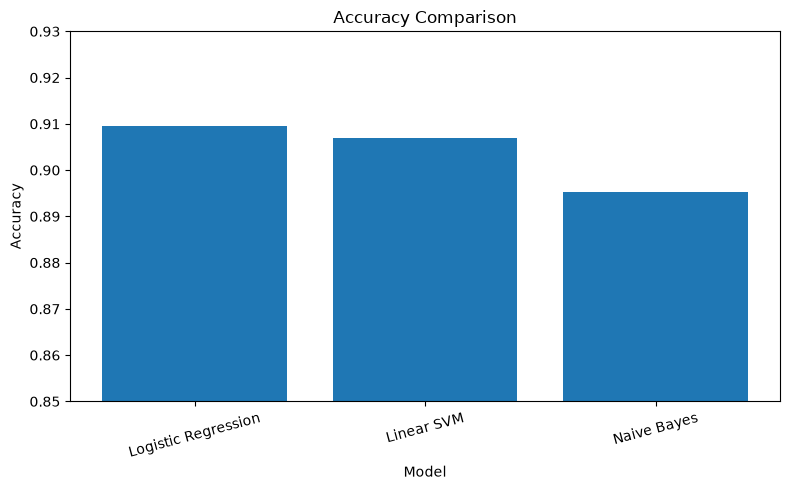

In [147]:
# ==========================================================
# MODEL COMPARISON - ACCURACY
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.85, 0.93)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

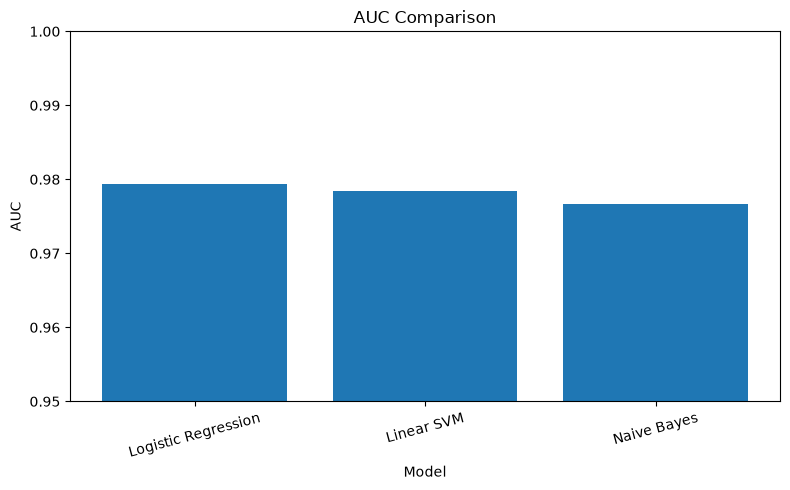

In [148]:
# ==========================================================
# MODEL COMPARISON - AUC
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["AUC"]
)

plt.title("AUC Comparison")
plt.xlabel("Model")
plt.ylabel("AUC")

plt.ylim(0.95, 1.00)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

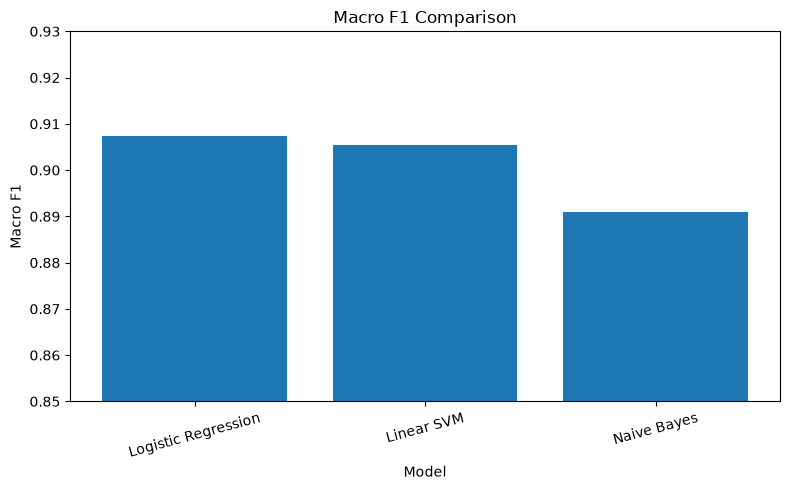

In [149]:
# ==========================================================
# MODEL COMPARISON - MACRO F1
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Macro F1"]
)

plt.title("Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1")

plt.ylim(0.85, 0.93)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [159]:
# ============================================================
# BONUS — WORD2VEC
# ============================================================

from gensim.models import Word2Vec
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    f1_score
)


# ============================================================
# 1. CHARGER D1
# ============================================================

d1_path = "../Data/preprocessed_data/D1_Original.csv"

df_w2v = pd.read_csv(d1_path)

print("Dataset utilisé : D1")
print("Nombre de tweets :", len(df_w2v))
print()


# ============================================================
# 2. PREPARER LES TWEETS
# ============================================================

sentences = (
    df_w2v["tweet"]
    .fillna("")
    .astype(str)
    .apply(str.split)
    .tolist()
)


# ============================================================
# 3. SEPARER TRAIN / TEST
# ============================================================

X_text_train, X_text_test, y_train_w2v, y_test_w2v = train_test_split(
    df_w2v["tweet"],
    df_w2v["sentiment"],
    test_size=0.20,
    random_state=42,
    stratify=df_w2v["sentiment"]
)


print("Train :", len(X_text_train))
print("Test  :", len(X_text_test))
print()


# ============================================================
# 4. ENTRAINER WORD2VEC SUR LE TRAIN UNIQUEMENT
# ============================================================

train_sentences = (
    X_text_train
    .fillna("")
    .astype(str)
    .apply(str.split)
    .tolist()
)


word2vec_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=42
)


print("Word2Vec entraîné avec succès.")
print("Taille du vocabulaire :", len(word2vec_model.wv))
print()


# ============================================================
# 5. TRANSFORMER UN TWEET EN VECTEUR
# ============================================================

def tweet_to_vector(tweet, model):

    words = tweet.split()

    vectors = [
        model.wv[word]
        for word in words
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


# ============================================================
# 6. TRANSFORMER TRAIN ET TEST EN VECTEURS WORD2VEC
# ============================================================

X_train_w2v = np.array([
    tweet_to_vector(tweet, word2vec_model)
    for tweet in X_text_train
])

X_test_w2v = np.array([
    tweet_to_vector(tweet, word2vec_model)
    for tweet in X_text_test
])


print("Word2Vec representations:")
print("X_train :", X_train_w2v.shape)
print("X_test  :", X_test_w2v.shape)
print()


# ============================================================
# 7. LOGISTIC REGRESSION + GRIDSEARCH
# ============================================================

param_grid_w2v = {
    "C": [0.01, 0.1, 1, 10, 100]
}


logistic_w2v = LogisticRegression(
    max_iter=2000,
    random_state=42
)


grid_w2v = GridSearchCV(
    estimator=logistic_w2v,
    param_grid=param_grid_w2v,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


grid_w2v.fit(
    X_train_w2v,
    y_train_w2v
)


# ============================================================
# 8. PREDICTIONS
# ============================================================

best_w2v_model = grid_w2v.best_estimator_

y_pred_w2v = best_w2v_model.predict(X_test_w2v)

y_proba_w2v = best_w2v_model.predict_proba(X_test_w2v)


# ============================================================
# 9. METRICS
# ============================================================

accuracy_w2v = accuracy_score(
    y_test_w2v,
    y_pred_w2v
)


auc_w2v = roc_auc_score(
    y_test_w2v,
    y_proba_w2v,
    multi_class="ovr",
    average="weighted"
)


macro_f1_w2v = f1_score(
    y_test_w2v,
    y_pred_w2v,
    average="macro"
)


# ============================================================
# 10. AFFICHER LES RESULTATS
# ============================================================

print("=" * 60)
print("WORD2VEC + LOGISTIC REGRESSION")
print("=" * 60)

print(
    "Best C :",
    grid_w2v.best_params_["C"]
)

print(
    "Best CV Score :",
    round(grid_w2v.best_score_, 6)
)

print(
    "Test Accuracy :",
    round(accuracy_w2v, 6)
)

print(
    "Test AUC :",
    round(auc_w2v, 6)
)

print(
    "Macro F1 :",
    round(macro_f1_w2v, 6)
)


print("\nClassification Report:")

print(
    classification_report(
        y_test_w2v,
        y_pred_w2v
    )
)


# ============================================================
# 11. RESULTAT FINAL WORD2VEC
# ============================================================

word2vec_results = pd.DataFrame([{
    "dataset": "D1",
    "vectorization": "Word2Vec",
    "model": "Logistic Regression",
    "best_C": grid_w2v.best_params_["C"],
    "cv_score": grid_w2v.best_score_,
    "accuracy": accuracy_w2v,
    "auc": auc_w2v,
    "macro_f1": macro_f1_w2v
}])


print("\nWord2Vec Results:")

display(word2vec_results)

Dataset utilisé : D1
Nombre de tweets : 3865

Train : 3092
Test  : 773

Word2Vec entraîné avec succès.
Taille du vocabulaire : 2261

Word2Vec representations:
X_train : (3092, 100)
X_test  : (773, 100)

WORD2VEC + LOGISTIC REGRESSION
Best C : 100
Best CV Score : 0.812732
Test Accuracy : 0.843467
Test AUC : 0.938847
Macro F1 : 0.840332

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.82      0.83       223
     neutral       0.84      0.89      0.87       313
    positive       0.86      0.80      0.83       237

    accuracy                           0.84       773
   macro avg       0.84      0.84      0.84       773
weighted avg       0.84      0.84      0.84       773


Word2Vec Results:


,dataset,vectorization,model,best_C,cv_score,accuracy,auc,macro_f1
0,D1,Word2Vec,Logistic Regression,100,0.812732,0.843467,0.938847,0.840332
